# 02 · Exploratory analysis

Acoustic summaries of the recordings before any modelling: amplitude and zero-crossing rate by
recording, by time of day, and against season, sea surface temperature and wind speed.

Two measurement variants are used throughout:

| variant | signal | used for |
|---|---|---|
| full band | normalised, unfiltered | zero-crossing rate |
| fish band | normalised, 100–2000 Hz band-pass | RMS amplitude |

Zero-crossing rate counts sign changes per sample, so band-limiting would make it a property of the
filter rather than of the sound. RMS is restricted to 100–2000 Hz, the range in which reef fish
sound is concentrated.

Recordings are included only where both fish counts and environmental readings are available.

Figures are written to `figures/eda/`.

In [1]:
import os, glob, re, warnings, calendar
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import signal, optimize, stats
from scipy.stats import pearsonr, spearmanr, linregress

warnings.filterwarnings("ignore")

BASE      = f"/scratch/{os.environ.get('USER','username')}/capstone"
WAV_DIR   = os.path.join(BASE, "audio")
FISH_CSV  = os.path.join(BASE, "Final_Fish_counts.csv")
WIND_CSV  = os.path.join(BASE, "Temp_Wind_Data.csv")
OUT_DIR   = os.path.join(BASE, "figures", "eda")
os.makedirs(OUT_DIR, exist_ok=True)

FRAME_LEN = 2048
HOP_LEN   = 512
LOW_HZ    = 100
HIGH_HZ   = 2000

FW = 6.69; FS_TK = 8; FS_AX = 9; FS_TT = 10; FS_LG = 8; LW = 0.75; DPI = 300
DAY_COL = "#E69F00"; NIGHT_COL = "#0072B2"
DAY_FILL = "#F6D998"; NIGHT_FILL = "#AFD3E6"
DAY_MK = "o"; NIGHT_MK = "s"; DAY_LS = "-"; NIGHT_LS = "--"

plt.rcParams.update({"font.family": "Arial", "font.size": FS_TK,
    "axes.linewidth": 0.5, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.labelsize": FS_TK, "ytick.labelsize": FS_TK,
    "legend.frameon": False, "legend.fontsize": FS_LG,
    "figure.dpi": DPI, "savefig.dpi": DPI})

# Legend order follows the order the seasons appear along the time axis.
SEASON_ORDER  = ["Summer", "Fall", "Winter", "Spring"]

def get_season(dt):
    if dt is None: return "Unknown"
    m = dt.month
    if m in [3,4,5]:   return "Spring"
    if m in [6,7,8]:   return "Summer"
    if m in [9,10,11]: return "Fall"
    return "Winter"

def parse_date(label):
    m = re.search(r"-(\d{6})-(\d{4})$", label)
    if m:
        try:
            dt = datetime.strptime("20" + m.group(1), "%Y%m%d")
            return dt.replace(hour=int(m.group(2)[:2]), minute=int(m.group(2)[2:]))
        except Exception:
            return None
    m2 = re.search(r"(\d{4}-\d{2}-\d{2})", label)
    if m2:
        try: return datetime.strptime(m2.group(1), "%Y-%m-%d")
        except Exception: return None
    return None

def is_night(label):
    m = re.search(r"-(\d{4})$", label)
    if m:
        h = int(m.group(1)); return h >= 2000 or h < 600
    return "night" in label.lower()

def rec_key(dt):
    return f"{dt.strftime('%Y-%m-%d')} {'Night' if (dt.hour >= 20 or dt.hour < 6) else 'Day'}"

def savefig(fig, fname):
    path = os.path.join(OUT_DIR, fname)
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"  saved: {fname}")

def _season_ranges(t_min, t_max):
    """Yield (season, start, end) spans clipped to [t_min, t_max], in chronological order.

    Winter runs December to February, so its span crosses a year boundary. Years are derived
    from the data range rather than fixed."""
    ORDERED = [("Summer", 6, 3), ("Fall", 9, 3), ("Winter", 12, 3), ("Spring", 3, 3)]
    for yr in range(pd.Timestamp(t_min).year - 1, pd.Timestamp(t_max).year + 2):
        for sname, start_mo, n_mo in ORDERED:
            sdates=[]
            for i in range(n_mo):
                total_mo = start_mo + i
                yr_this  = yr if total_mo <= 12 else yr+1
                mo_this  = total_mo if total_mo <= 12 else total_mo - 12
                sdates.append(pd.Timestamp(yr_this, mo_this, 1))
                sdates.append(pd.Timestamp(yr_this, mo_this,
                                           calendar.monthrange(yr_this, mo_this)[1]))
            if not sdates: continue
            sb=max(min(sdates),t_min); se=min(max(sdates),t_max)
            if sb<se: yield sname,sb,se

# Seasonal background shading, colour-blind safe and distinct from the day/night palette.
SEASON_BG={'Spring':'#CFE3C6','Summer':'#EBE0C4','Fall':'#E6CBCB','Winter':'#D5D6E6'}
SEASON_BG_ALPHA=0.6

def add_season_bg_dates(ax,t_min,t_max,alpha=SEASON_BG_ALPHA):
    """Shade seasons behind a DATE x-axis chart."""
    for sname,sb,se in _season_ranges(pd.Timestamp(t_min),pd.Timestamp(t_max)):
        ax.axvspan(mdates.date2num(sb),mdates.date2num(se),
                   facecolor=SEASON_BG.get(sname,'#FFFFFF'),alpha=alpha,lw=0,zorder=0)

def add_season_bg_days(ax,t_min,t_max,alpha=SEASON_BG_ALPHA):
    """Shade seasons behind a DAYS-since-first x-axis chart."""
    if t_min is None or t_max is None: return
    t0=pd.Timestamp(t_min)
    for sname,sb,se in _season_ranges(t0,pd.Timestamp(t_max)):
        ax.axvspan((sb-t0).days,(se-t0).days,
                   facecolor=SEASON_BG.get(sname,'#FFFFFF'),alpha=alpha,lw=0,zorder=0)

def _blend(h,a,bg=(255,255,255)):
    c=[int(h[i:i+2],16) for i in (1,3,5)]
    return tuple((a*c[k]+(1-a)*bg[k])/255 for k in range(3))
def season_legend_handles():
    return [mpatches.Patch(facecolor=_blend(SEASON_BG[s],SEASON_BG_ALPHA),
            edgecolor='#C8C8C8',lw=0.4,label=s) for s in SEASON_ORDER]
def dn_season_handles():
    return [Line2D([0],[0],color=DAY_COL,marker=DAY_MK,ls=DAY_LS,label='Day',lw=1.3,ms=4),
            Line2D([0],[0],color=NIGHT_COL,marker=NIGHT_MK,ls=NIGHT_LS,label='Night',lw=1.3,ms=4)
            ]+season_legend_handles()

## Recordings

Only recordings that appear in both the fish count table and the environmental table are used.

In [2]:
import librosa

fish = pd.read_csv(FISH_CSV, index_col=0)
fish.index = fish.index.astype(str).str.strip()

wind_raw = pd.read_csv(WIND_CSV)
_dt = pd.to_datetime(wind_raw["DateTime"], format="mixed")
wind_raw["recording_key"] = (_dt.dt.strftime("%Y-%m-%d") + " " +
    np.where((_dt.dt.hour >= 20) | (_dt.dt.hour < 6), "Night", "Day"))

KEEP = set(fish.index) & set(wind_raw["recording_key"])
print(f"fish counts: {len(fish)} | environmental: {len(wind_raw)} | both: {len(KEEP)}")

wav_paths = sorted(glob.glob(os.path.join(WAV_DIR, "**", "*.wav"), recursive=True))
if not wav_paths:
    raise SystemExit(f"no .wav files under {WAV_DIR}")

recordings, skipped = [], []
for p in wav_paths:
    label = os.path.splitext(os.path.basename(p))[0]
    dt = parse_date(label)
    if dt is None or rec_key(dt) not in KEEP:
        skipped.append(label); continue
    y, sr = librosa.load(p, sr=None, mono=True)
    recordings.append({"label": label, "key": rec_key(dt), "y_raw": y.copy(),
                       "sr": sr, "night": is_night(label), "dt": dt})

recordings.sort(key=lambda r: r["dt"])
print(f"loaded {len(recordings)} recordings | skipped {len(skipped)} without matching data")
missing = sorted(KEEP - {r['key'] for r in recordings})
if missing:
    print(f"no audio on disk for {len(missing)} recording(s): {missing[:5]}")

fish counts: 72 | environmental: 72 | both: 72
loaded 72 recordings | skipped 3 without matching data


## Signal preparation

Each recording is normalised by its peak amplitude. The fish-band variant is then band-passed to
100–2000 Hz with a fourth-order zero-phase Butterworth filter.

In [3]:
def apply_bandpass(y, sr, lo=LOW_HZ, hi=HIGH_HZ, order=4):
    nyq = sr / 2.0
    lo = max(lo, 1.0); hi = min(hi, nyq * 0.99)
    if lo >= hi or len(y) < 3 * (order * 2 + 1):
        return y
    b, a = signal.butter(order, [lo / nyq, hi / nyq], btype="band")
    return signal.filtfilt(b, a, y).astype(np.float32)

for r in recordings:
    y = r["y_raw"]
    r["y_full"] = (y / (np.max(np.abs(y)) + 1e-9)).astype(np.float32)
    r["y_band"] = apply_bandpass(r["y_full"], r["sr"])

print(f"full band: {len(recordings)} recordings")
print(f"fish band: {LOW_HZ}-{HIGH_HZ} Hz")

full band: 72 recordings
fish band: 100-2000 Hz


## Frame-level metrics

RMS and zero-crossing rate are computed over 2048-sample frames with a 512-sample hop, then
summarised per recording as the mean, standard deviation and five percentiles.

In [4]:
def rms_frames(y):
    n = (len(y) - FRAME_LEN) // HOP_LEN + 1
    if n <= 0: return np.array([], dtype=np.float32)
    frames = np.lib.stride_tricks.as_strided(
        y, shape=(n, FRAME_LEN), strides=(y.strides[0] * HOP_LEN, y.strides[0]))
    return np.sqrt(np.mean(frames.astype(np.float64) ** 2, axis=1)).astype(np.float32)

def zcr_frames(y):
    out = []
    for s in range(0, len(y) - FRAME_LEN + 1, HOP_LEN):
        f = y[s:s + FRAME_LEN]
        out.append(np.sum(np.diff(np.sign(f)) != 0) / FRAME_LEN)
    return np.array(out, dtype=np.float32)

def pct(a, p): return float(np.percentile(a, p)) if len(a) else np.nan
def mn(a):     return float(np.mean(a)) if len(a) else np.nan
def sd(a):     return float(np.std(a)) if len(a) else np.nan

t0g = min(r["dt"] for r in recordings)

rows_A, rows_B = [], []
for r in recordings:
    zA = zcr_frames(r["y_full"]); rA = rms_frames(r["y_full"])
    zB = zcr_frames(r["y_band"]); rB = rms_frames(r["y_band"])
    base = {"label": r["label"], "dt_lbl": r["dt"].strftime("%d %b %Y"), "night": r["night"],
            "dt": r["dt"], "season": get_season(r["dt"]), "days": (r["dt"] - t0g).days}
    for rows, rr, zz in [(rows_A, rA, zA), (rows_B, rB, zB)]:
        rows.append({**base,
            "rms_mean": mn(rr), "rms_std": sd(rr),
            "rms_p10": pct(rr,10), "rms_p25": pct(rr,25), "rms_p50": pct(rr,50),
            "rms_p75": pct(rr,75), "rms_p90": pct(rr,90),
            "zcr_mean": mn(zz), "zcr_std": sd(zz),
            "zcr_p10": pct(zz,10), "zcr_p25": pct(zz,25), "zcr_p50": pct(zz,50),
            "zcr_p75": pct(zz,75), "zcr_p90": pct(zz,90)})

smry_A = pd.DataFrame(rows_A)   # full band  — zero-crossing rate
smry_B = pd.DataFrame(rows_B)   # fish band  — RMS amplitude
assert len(smry_A) == len(recordings)
print(f"{len(smry_A)} recordings | {int(smry_A['night'].sum())} night, "
      f"{int((~smry_A['night']).sum())} day")
print(smry_A["season"].value_counts().reindex(SEASON_ORDER).to_string())

72 recordings | 39 night, 33 day
season
Summer    17
Fall      22
Winter    11
Spring    22


## Figure 1a — RMS amplitude by recording

  saved: Fig1a_RMS_boxplot.png


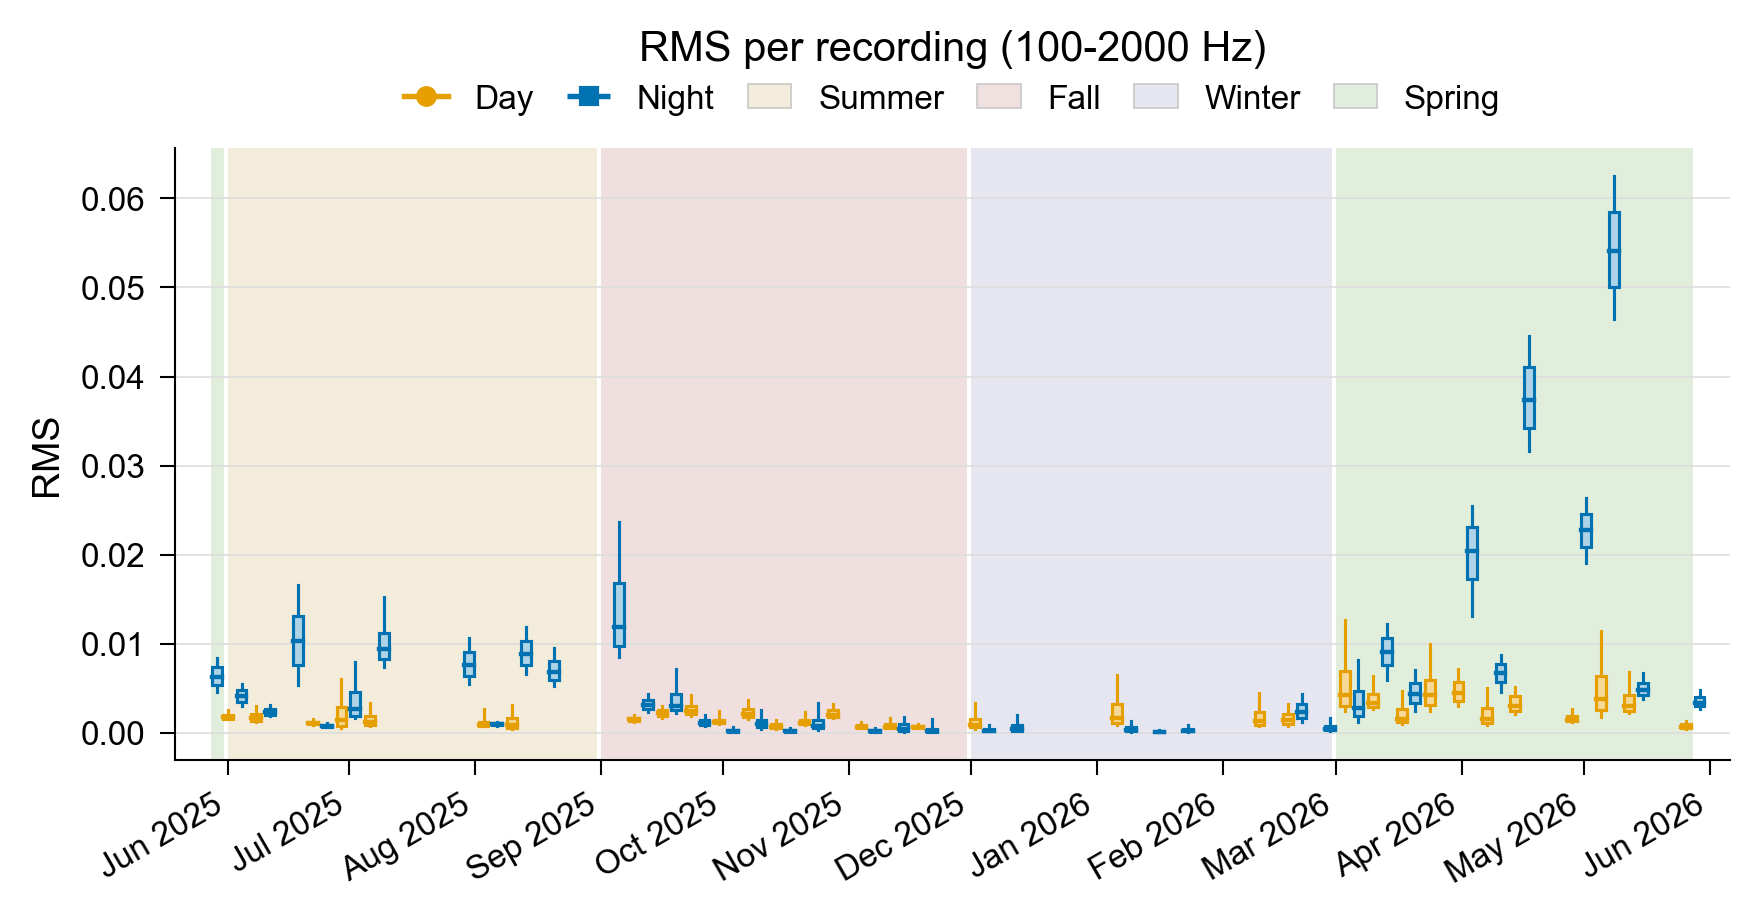

In [5]:
order=sorted(range(len(recordings)),key=lambda i:recordings[i]['dt'] or datetime(2000,1,1))
sA=smry_A.iloc[order].reset_index(drop=True)
sB=smry_B.iloc[order].reset_index(drop=True)
n=len(order)

def draw_vbox(smry,p10,p25,p50,p75,p90,ylabel,title,fname):
    """Vertical per-recording distribution boxes; DATE on x-axis, value on y-axis."""
    df=smry[smry['dt'].notna()].copy()
    t_min=pd.to_datetime(df['dt']).min(); t_max=pd.to_datetime(df['dt']).max()
    fig,ax=plt.subplots(figsize=(FW,3.4)); fig.subplots_adjust(top=0.80,bottom=0.22)
    add_season_bg_dates(ax,t_min,t_max)
    W=2.4
    for _,row in df.iterrows():
        c =DAY_COL  if not row['night'] else NIGHT_COL
        fc=DAY_FILL if not row['night'] else NIGHT_FILL
        off=-1.5 if not row['night'] else 1.5
        x=mdates.date2num(pd.to_datetime(row['dt']))+off
        lo,q1,med,q3,hi=row[p10],row[p25],row[p50],row[p75],row[p90]
        if any(pd.isna(v) for v in [lo,q1,med,q3,hi]): continue
        ax.plot([x,x],[lo,q1],color=c,lw=LW,zorder=3); ax.plot([x,x],[q3,hi],color=c,lw=LW,zorder=3)
        ax.add_patch(plt.Rectangle((x-W/2,q1),W,q3-q1,facecolor=fc,edgecolor=c,lw=LW,zorder=3))
        ax.plot([x-W/2,x+W/2],[med,med],color=c,lw=LW*1.4,zorder=4)
    ax.set_xlim(mdates.date2num(t_min)-9,mdates.date2num(t_max)+9)
    ax.set_ylabel(ylabel,fontsize=FS_AX)
    ax.spines[['top','right']].set_visible(False); ax.grid(axis='y',color='#DDD',lw=0.4,zorder=1)
    ax.xaxis_date(); ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    fig.autofmt_xdate(rotation=30,ha='right')
    ax.legend(handles=dn_season_handles(),loc='lower center',bbox_to_anchor=(0.5,1.005),
              ncol=6,fontsize=FS_LG,frameon=False,handlelength=1.3,columnspacing=1.0)
    ax.text(0.5,1.13,title,transform=ax.transAxes,ha='center',va='bottom',fontsize=FS_TT,clip_on=False)
    savefig(fig,fname); plt.show(); plt.close(fig)

# Fig 1a -- RMS distribution per recording (100-2000 Hz)  [sB]
draw_vbox(sB,'rms_p10','rms_p25','rms_p50','rms_p75','rms_p90',
          'RMS','RMS per recording (100-2000 Hz)','Fig1a_RMS_boxplot.png')

## Figure 1b — Zero-crossing rate by recording

  saved: Fig1b_ZCR_boxplot.png


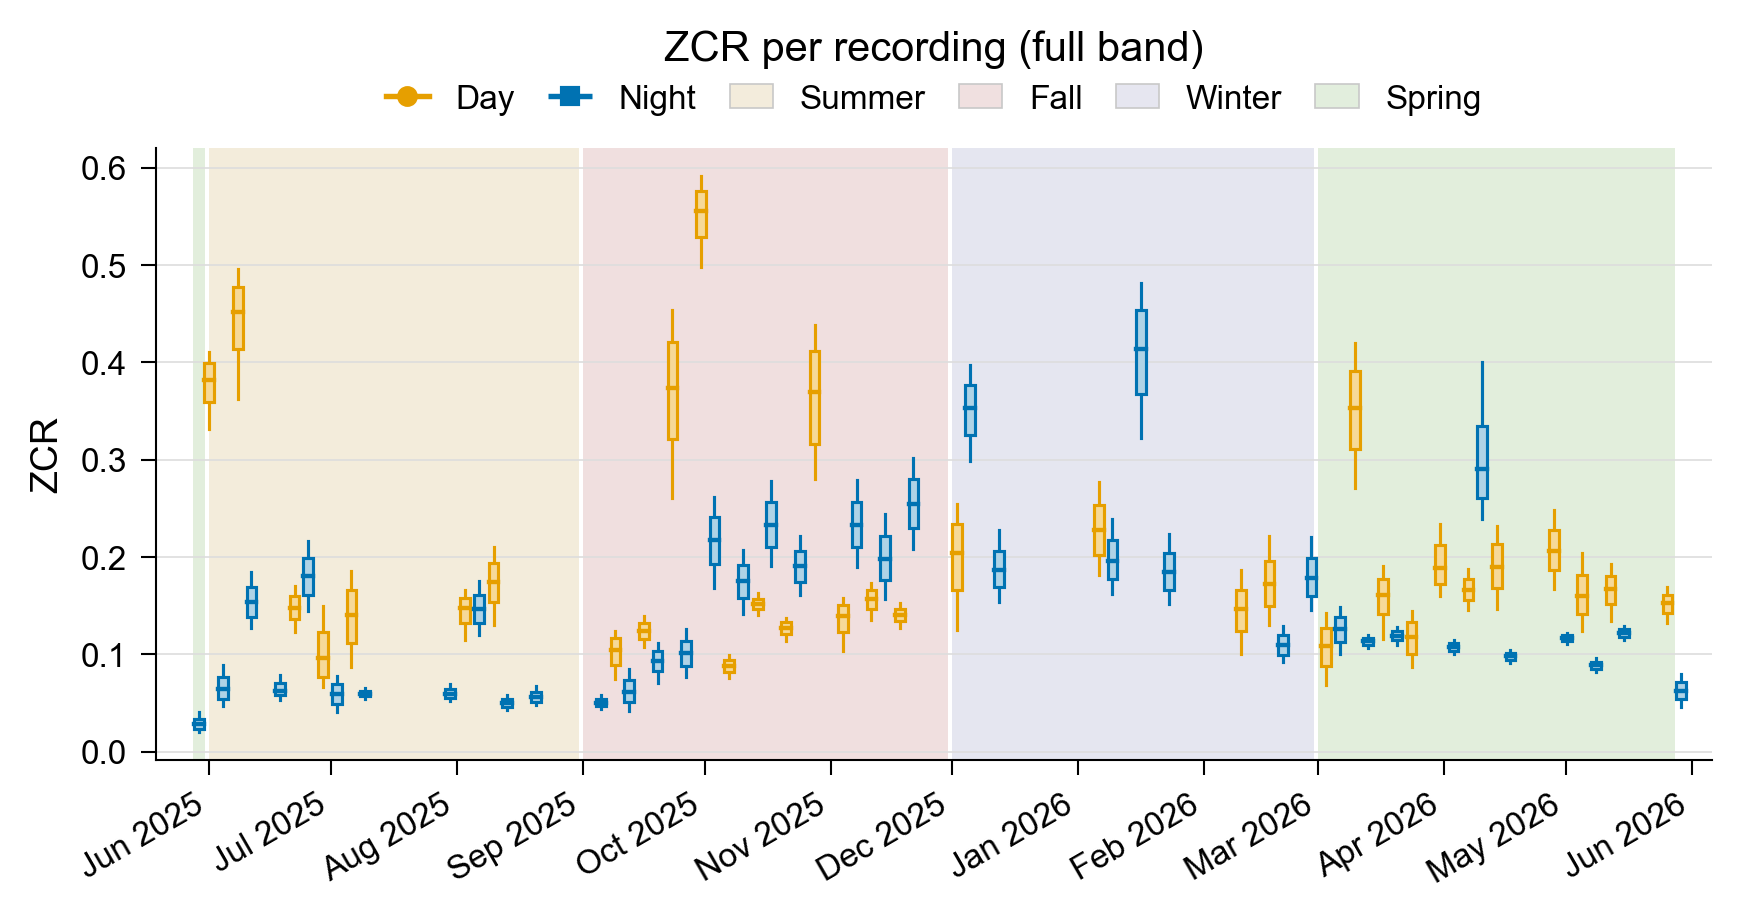

In [6]:
# Fig 1b -- ZCR distribution per recording (full band)  [sA]
draw_vbox(sA,'zcr_p10','zcr_p25','zcr_p50','zcr_p75','zcr_p90',
          'ZCR','ZCR per recording (full band)','Fig1b_ZCR_boxplot.png')

## Figure 2 — Day versus night

  saved: Fig2a_RMS_DayNight.png


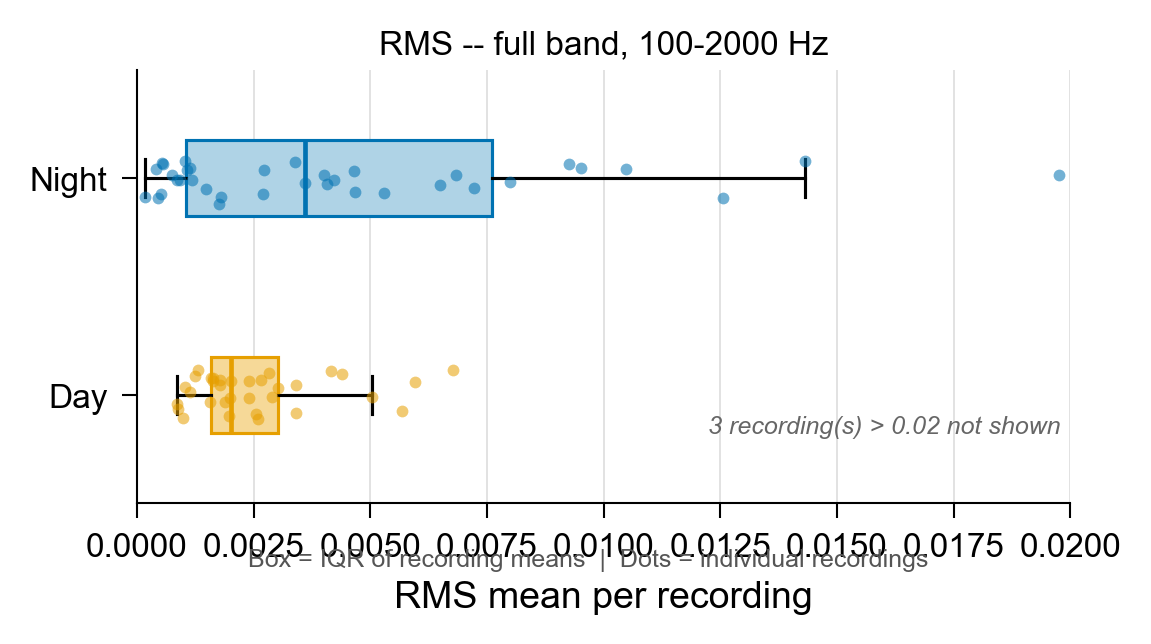

  saved: Fig2b_ZCR_DayNight.png


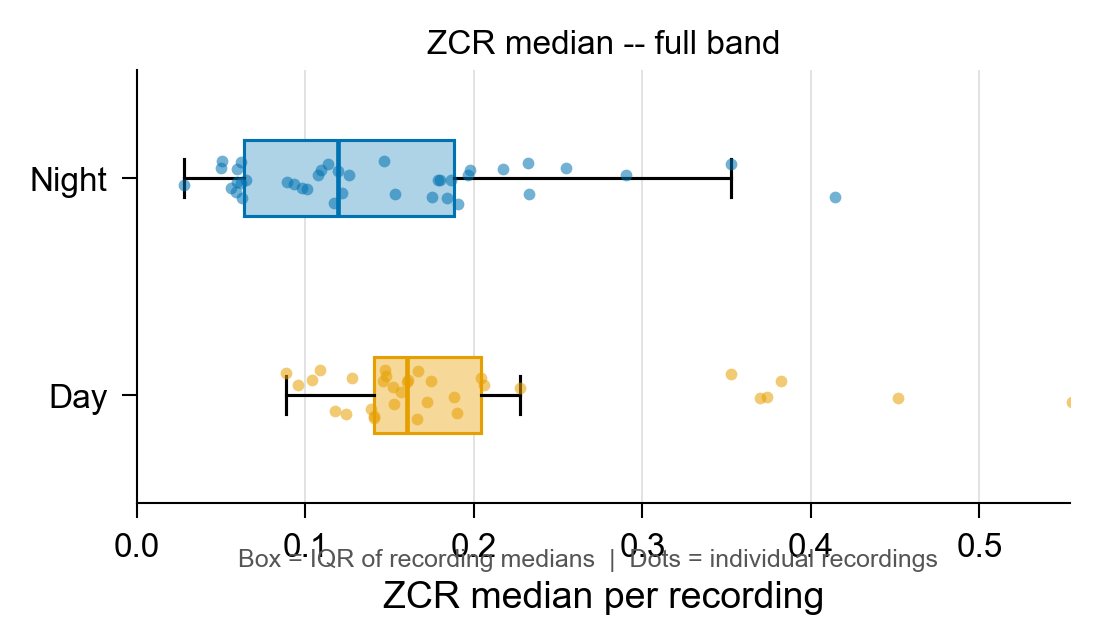

In [7]:
def bplot_dn_horiz(ax, day_df, ngt_df, col, xlabel):
    """Horizontal box plot with individual recording dots overlaid.
    X = metric mean per recording. Y = Day / Night.
    Dots show every individual recording mean so outliers are visible.
    """
    data = [day_df[col].dropna().values, ngt_df[col].dropna().values]
    bp = ax.boxplot(data, vert=False, widths=0.35, patch_artist=True,
                   medianprops=dict(color='black', lw=LW*1.5),
                   whiskerprops=dict(color='black', lw=LW),
                   capprops=dict(color='black', lw=LW),
                   flierprops=dict(marker='', markersize=0),
                   boxprops=dict(lw=LW))
    bp['boxes'][0].set_facecolor(DAY_FILL);  bp['boxes'][0].set_edgecolor(DAY_COL)
    bp['boxes'][1].set_facecolor(NIGHT_FILL); bp['boxes'][1].set_edgecolor(NIGHT_COL)
    bp['medians'][0].set_color(DAY_COL); bp['medians'][1].set_color(NIGHT_COL)

    # Overlay individual recording means as dots
    rng = np.random.default_rng(42)
    for xi, (df_g, y_pos, col2) in enumerate(
        [(day_df, 1, DAY_COL), (ngt_df, 2, NIGHT_COL)], 0):
        vals = df_g[col].dropna().values
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(vals, y_pos + jitter, color=col2, s=8,
                   alpha=0.55, lw=0, zorder=5)

    # Default x-limit: 99th percentile * 1.15 to leave a little breathing room.
    # For RMS this is overridden to 0.02 in the calling code (with explicit count).
    all_vals = np.concatenate([d for d in data if len(d)>0])
    if len(all_vals)>0:
        ax.set_xlim(0, np.percentile(all_vals, 99) * 1.15)

    ax.set_yticks([1, 2])
    ax.set_yticklabels(['Day', 'Night'], fontsize=FS_TK)
    ax.set_xlabel(xlabel, fontsize=FS_AX)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', color='#DDD', lw=0.4)

day_A=smry_A[~smry_A['night']]; ngt_A=smry_A[smry_A['night']]
day_B=smry_B[~smry_B['night']]; ngt_B=smry_B[smry_B['night']]

# Figure 1 shows the distribution of per-frame RMS within each recording; this
# figure shows one mean per recording, so the scales differ.

fig,ax=plt.subplots(figsize=(FW*0.6, 1.9))
bplot_dn_horiz(ax, day_B, ngt_B, 'rms_mean', 'RMS mean per recording')
# Fix RMS x-axis to 0.02; count and annotate points beyond
all_rms_vals = np.concatenate([day_B['rms_mean'].dropna().values,
                               ngt_B['rms_mean'].dropna().values])
n_beyond_rms = int(np.sum(all_rms_vals > 0.02))
ax.set_xlim(0, 0.02)
if n_beyond_rms > 0:
    ax.text(0.99, 0.15, f'{n_beyond_rms} recording(s) > 0.02 not shown',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=6, color='#666', style='italic')
ax.set_title('RMS -- full band, 100-2000 Hz', fontsize=FS_TK, pad=4)
# Subtitle at bottom of figure, no overlap with title
fig.text(0.5, 0.0, 'Box = IQR of recording means  |  Dots = individual recordings',
         ha='center', va='bottom', fontsize=6, color='#555',
         transform=fig.transFigure)
fig.subplots_adjust(bottom=0.12)
savefig(fig,'Fig2a_RMS_DayNight.png'); plt.show(); plt.close(fig)

fig,ax=plt.subplots(figsize=(FW*0.6, 1.9))
bplot_dn_horiz(ax, day_A, ngt_A, 'zcr_p50', 'ZCR median per recording')
ax.set_title('ZCR median -- full band', fontsize=FS_TK, pad=4)
fig.text(0.5, 0.0, 'Box = IQR of recording medians  |  Dots = individual recordings',
         ha='center', va='bottom', fontsize=6, color='#555',
         transform=fig.transFigure)
fig.subplots_adjust(bottom=0.12)
savefig(fig,'Fig2b_ZCR_DayNight.png'); plt.show(); plt.close(fig)

## Figure 3 — Seasonal trend

  saved: Fig3a_RMS_trend.png


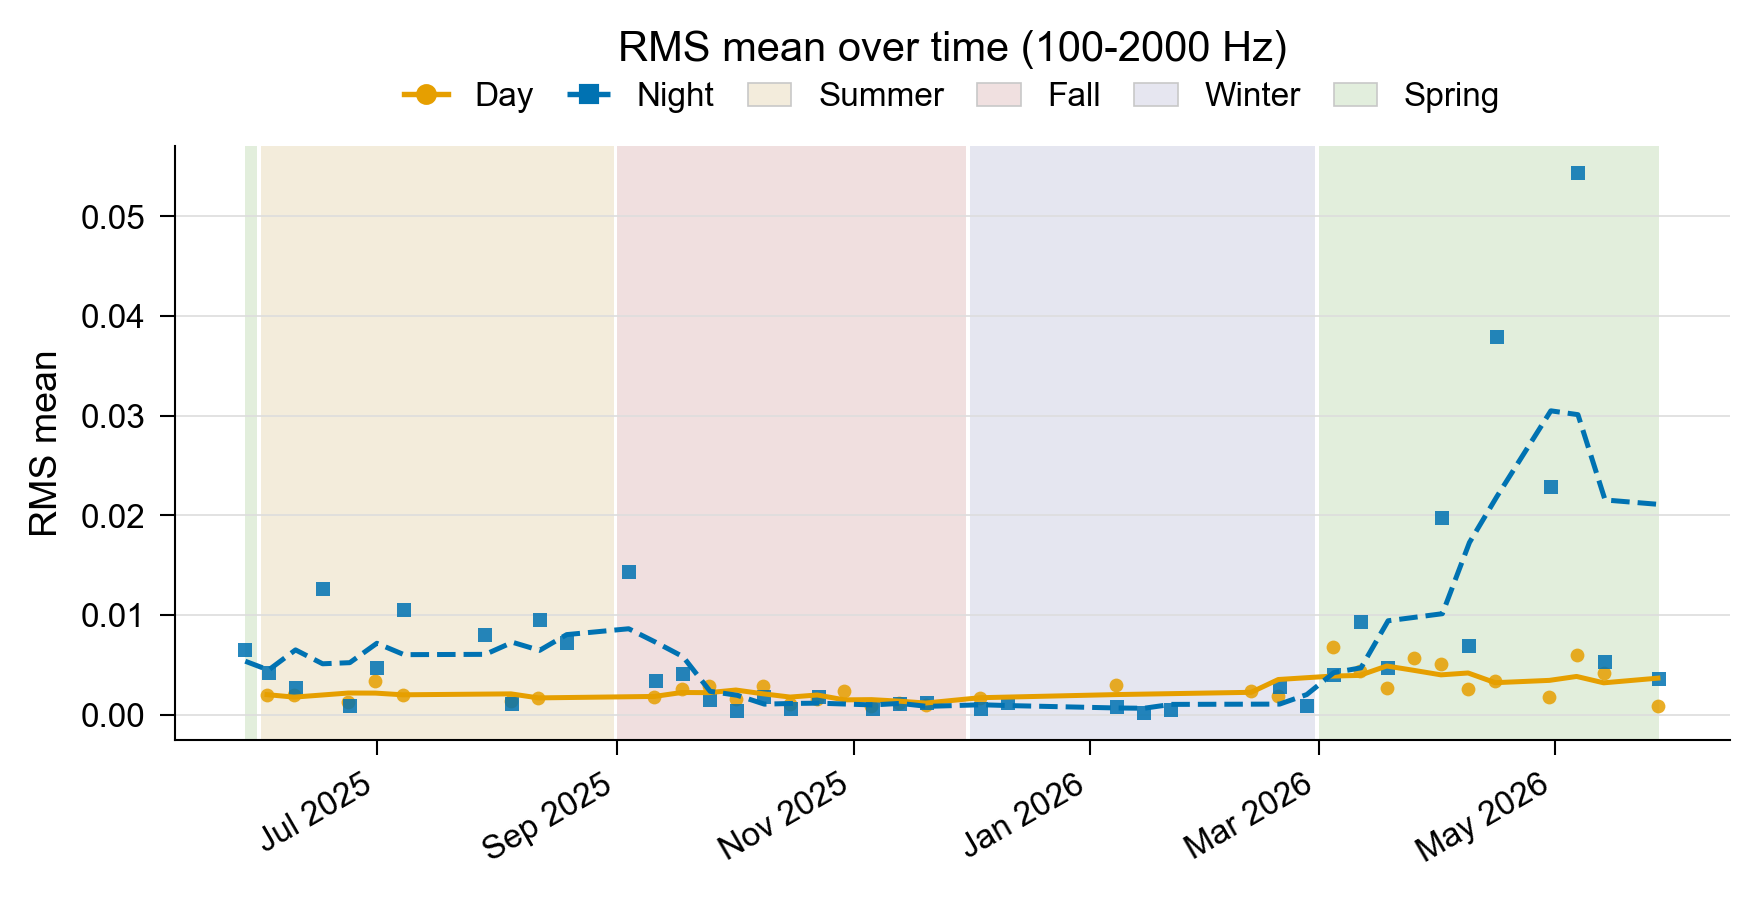

  saved: Fig3b_ZCR_trend.png


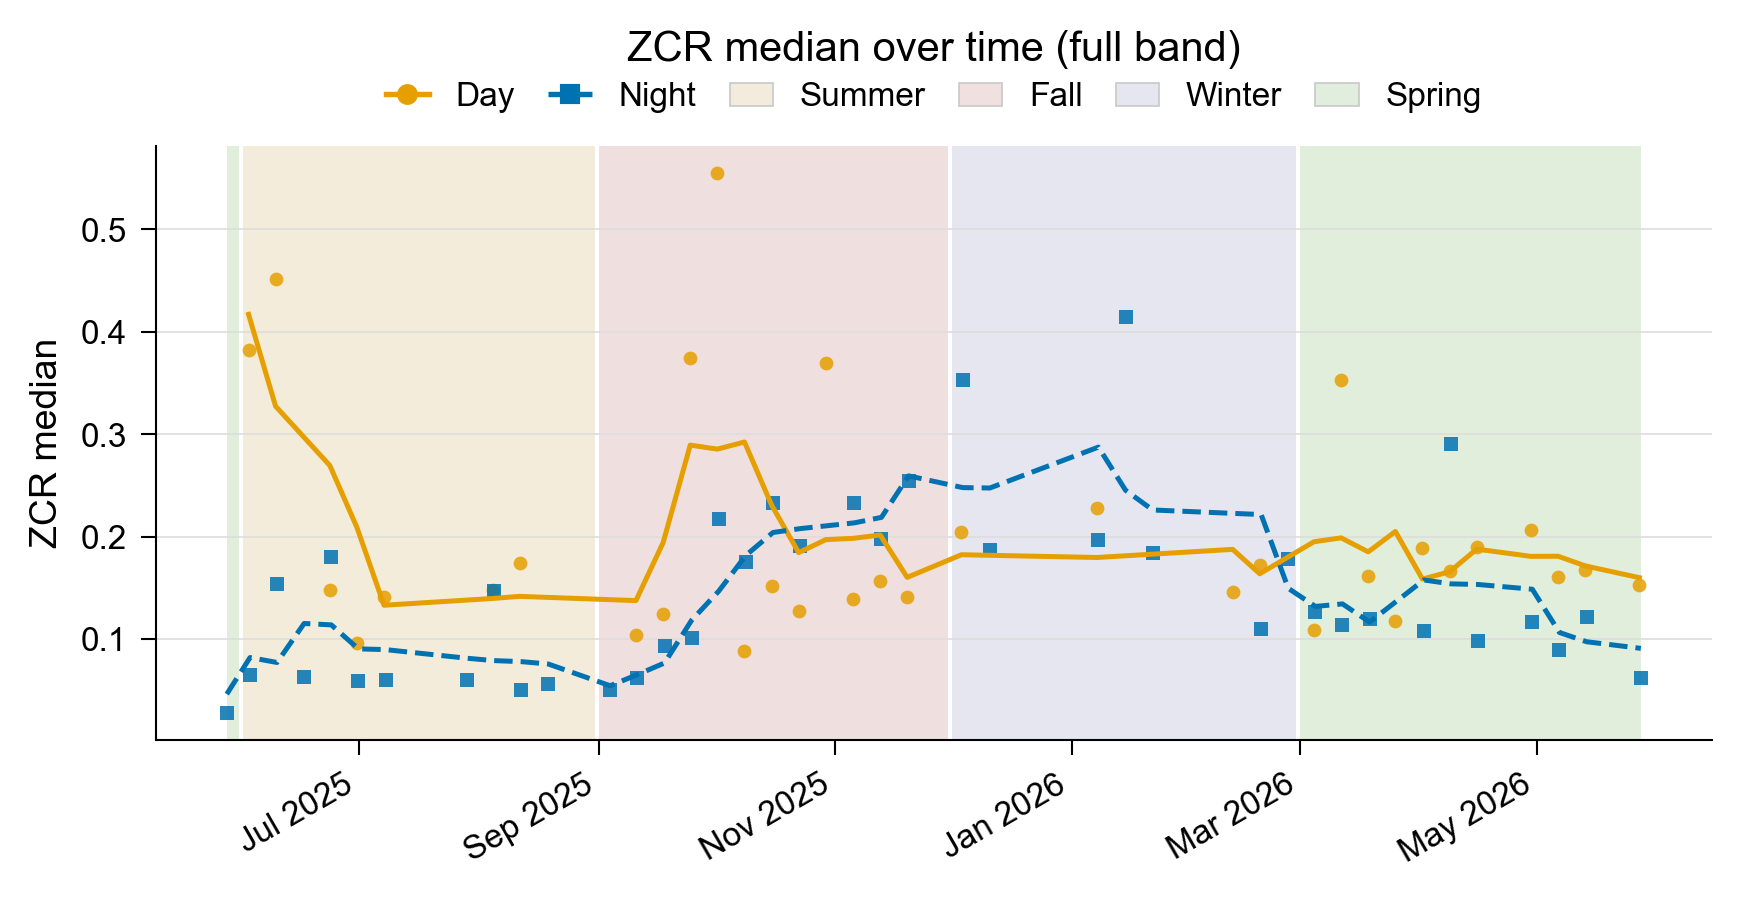

In [8]:
def seasonal_trend(smry, col, ylabel, title, fname):
    df = smry[smry['dt'].notna()].sort_values('dt').reset_index(drop=True)
    t_min = pd.to_datetime(df['dt']).min(); t_max = pd.to_datetime(df['dt']).max()
    fig, ax = plt.subplots(figsize=(FW, 3.3)); fig.subplots_adjust(top=0.80, bottom=0.20)
    ax.spines[['top','right']].set_visible(False); ax.grid(axis='y', color='#DDD', lw=0.4)
    add_season_bg_dates(ax, t_min, t_max)
    for night,col2,mk,ls,lbl in [
        (False,DAY_COL,DAY_MK,DAY_LS,'Day'),(True,NIGHT_COL,NIGHT_MK,NIGHT_LS,'Night')]:
        sub=df[df['night']==night].dropna(subset=[col]).sort_values('dt')
        if sub.empty: continue
        dts=pd.to_datetime(sub['dt'])
        ax.scatter(dts,sub[col],color=col2,marker=mk,s=11,alpha=0.85,lw=0,zorder=3)
        if len(sub)>=4:
            roll=sub[col].rolling(4,min_periods=1,center=True).mean()
            ax.plot(dts,roll,color=col2,lw=LW*1.6,ls=ls,zorder=4)
    ax.set_ylabel(ylabel, fontsize=FS_AX); ax.tick_params(labelsize=FS_TK)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')); fig.autofmt_xdate(rotation=30, ha='right')
    ax.legend(handles=dn_season_handles(), loc='lower center', bbox_to_anchor=(0.5,1.005),
              ncol=6, fontsize=FS_LG, frameon=False, handlelength=1.3, columnspacing=1.0)
    ax.text(0.5, 1.13, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=FS_TT, clip_on=False)
    savefig(fig, fname); plt.show(); plt.close(fig)

seasonal_trend(smry_B,'rms_mean','RMS mean',
    'RMS mean over time (100-2000 Hz)','Fig3a_RMS_trend.png')
seasonal_trend(smry_A,'zcr_p50','ZCR median',
    'ZCR median over time (full band)','Fig3b_ZCR_trend.png')

## Figure 4 — Harmonic regression

A two-term harmonic model with annual and
semi-annual components, fitted by least squares.

  saved: Fig4a_RMS_harmonic.png


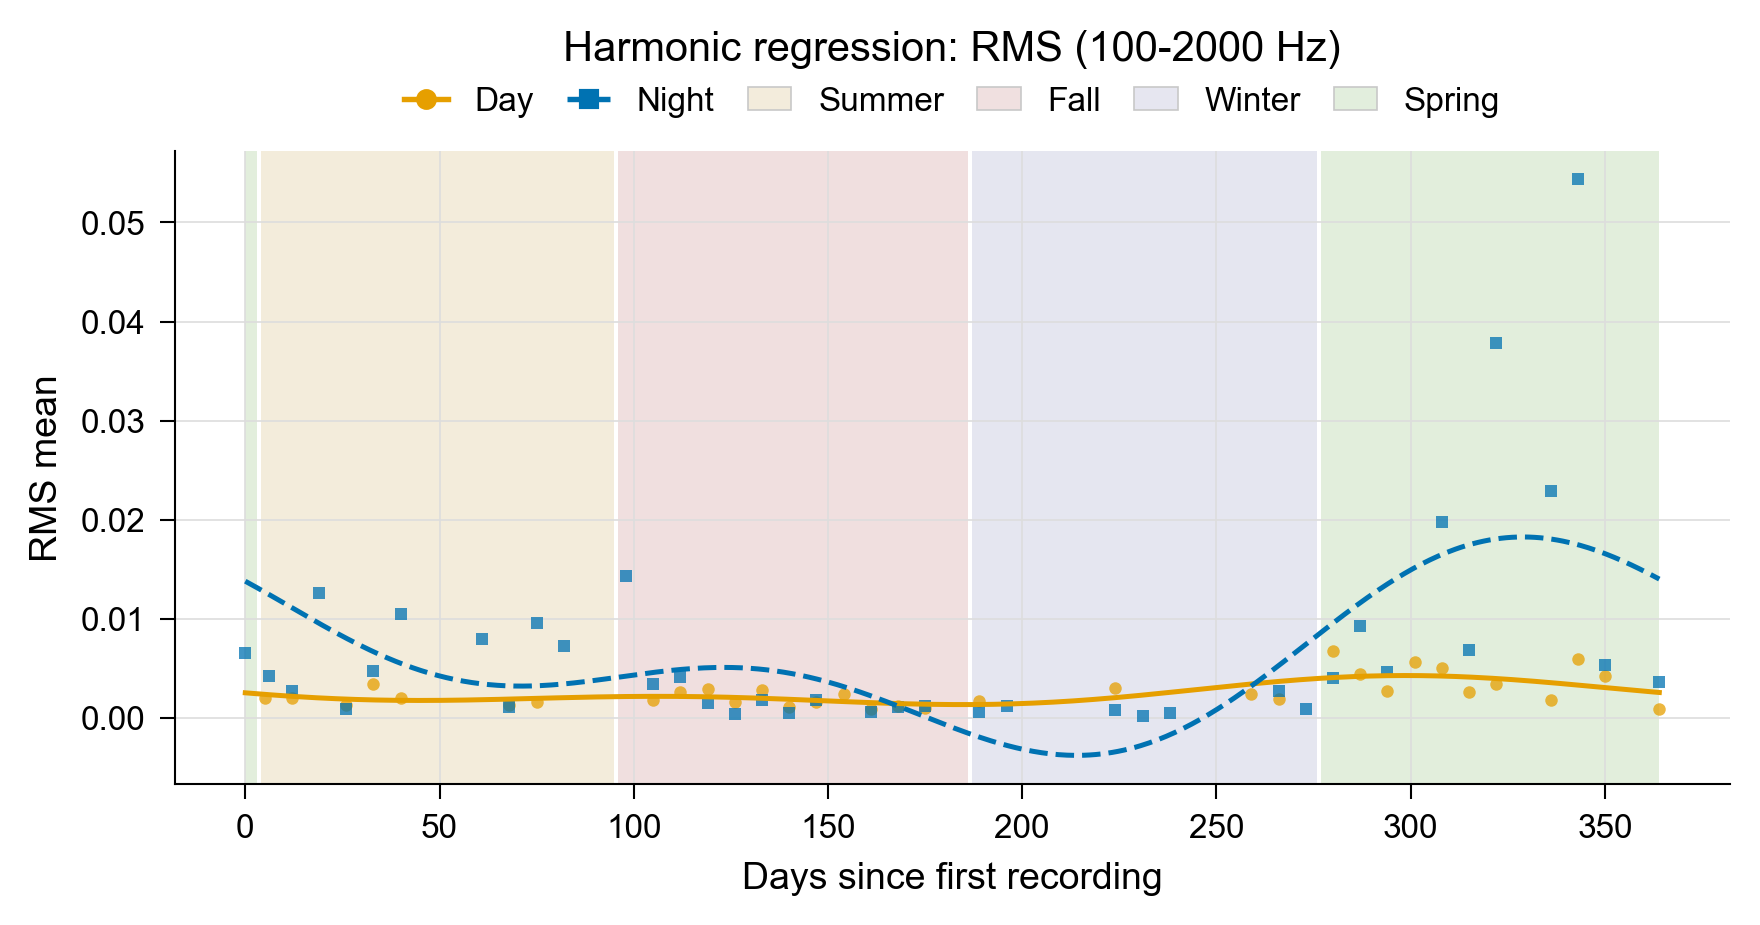

  saved: Fig4b_ZCR_harmonic.png


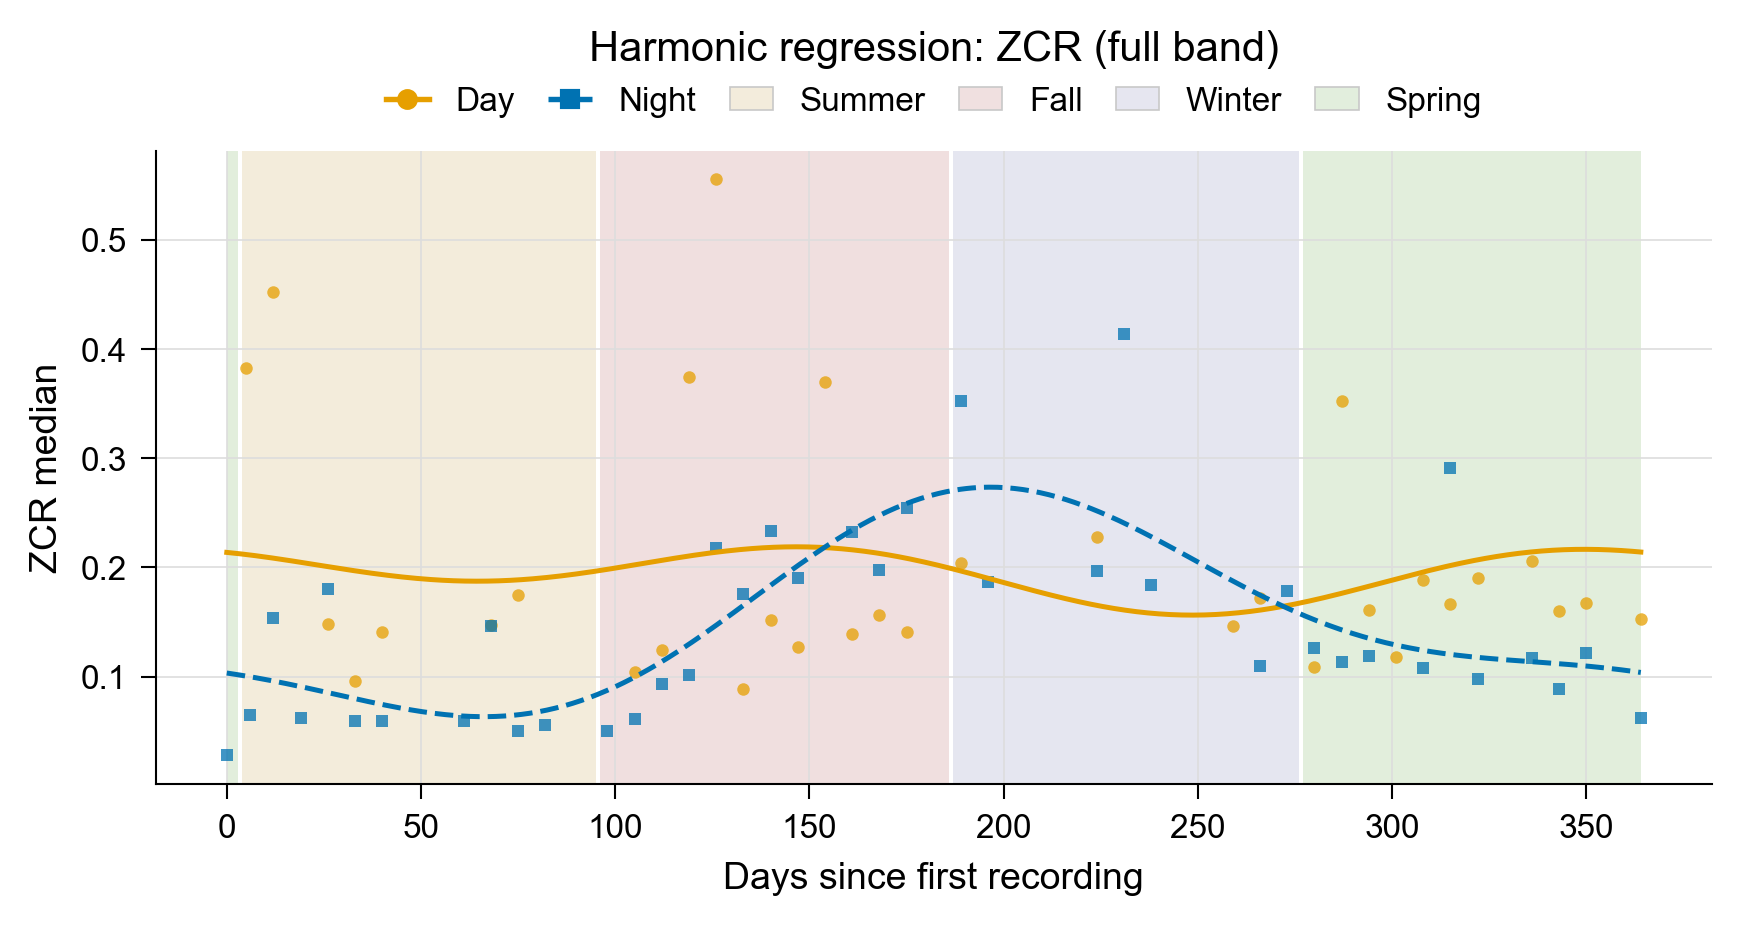

In [9]:
def hmodel(t,A0,A1,B1,A2,B2,T=365.0):
    return A0+A1*np.cos(2*np.pi*t/T)+B1*np.sin(2*np.pi*t/T)+A2*np.cos(4*np.pi*t/T)+B2*np.sin(4*np.pi*t/T)

def harm_plot(smry, col, ylabel, title, fname):
    df = smry[smry['days'].notna()].dropna(subset=[col]).copy(); df['t']=df['days'].astype(float)
    all_dts2=[r['dt'] for r in recordings if r['dt']]
    t_min2=min(all_dts2) if all_dts2 else None; t_max2=max(all_dts2) if all_dts2 else None
    fig,ax=plt.subplots(figsize=(FW,3.3)); fig.subplots_adjust(top=0.80,bottom=0.16)
    ax.spines[['top','right']].set_visible(False); ax.grid(color='#DDD',lw=0.4)
    add_season_bg_days(ax, t_min2, t_max2)
    for night,col2,mk,ls,lbl in [
        (False,DAY_COL,DAY_MK,DAY_LS,'Day'),(True,NIGHT_COL,NIGHT_MK,NIGHT_LS,'Night')]:
        sub=df[df['night']==night].sort_values('t')
        if sub.empty: continue
        t_obs=sub['t'].values; y_obs=sub[col].values
        ax.scatter(t_obs,y_obs,color=col2,marker=mk,s=9,alpha=0.75,lw=0,zorder=3)
        try:
            popt,_=optimize.curve_fit(hmodel,t_obs,y_obs,p0=[y_obs.mean(),0.01,0.01,0.005,0.005],maxfev=10000)
            tf=np.linspace(0,max(t_obs),500); ax.plot(tf,hmodel(tf,*popt),color=col2,lw=LW*1.6,ls=ls,zorder=4)
        except RuntimeError:
            pass          # curve_fit did not converge for this subset
    ax.set_xlabel('Days since first recording',fontsize=FS_AX); ax.set_ylabel(ylabel,fontsize=FS_AX)
    ax.tick_params(labelsize=FS_TK)
    ax.legend(handles=dn_season_handles(), loc='lower center', bbox_to_anchor=(0.5,1.005),
              ncol=6, fontsize=FS_LG, frameon=False, handlelength=1.3, columnspacing=1.0)
    ax.text(0.5,1.13,title,transform=ax.transAxes,ha='center',va='bottom',fontsize=FS_TT,clip_on=False)
    savefig(fig,fname); plt.show(); plt.close(fig)

harm_plot(smry_B,'rms_mean','RMS mean',
    'Harmonic regression: RMS (100-2000 Hz)','Fig4a_RMS_harmonic.png')
harm_plot(smry_A,'zcr_p50','ZCR median',
    'Harmonic regression: ZCR (full band)','Fig4b_ZCR_harmonic.png')

## Environmental data

Sea surface temperature and wind speed are matched to each recording by nearest timestamp within
four hours.

In [10]:
wind_df = pd.read_csv(WIND_CSV, parse_dates=["DateTime"])
wind_df = wind_df.rename(columns={"DateTime": "dt_wind", "WSPD_mps": "wspd",
                                  "WDIR_deg": "wdir", "SST_c": "sst"})
for col, sentinels in [("sst", [99., 999., 9999.]), ("wspd", [99., 999., 9999.]),
                       ("wdir", [999., 9999.])]:
    wind_df.loc[wind_df[col].isin(sentinels), col] = np.nan
wind_df = wind_df.dropna(subset=["dt_wind"]).sort_values("dt_wind").reset_index(drop=True)

def merge_env(smry):
    s = smry[smry["dt"].notna()].copy()
    s["dt"] = pd.to_datetime(s["dt"])
    return pd.merge_asof(s.sort_values("dt"), wind_df, left_on="dt", right_on="dt_wind",
                         tolerance=pd.Timedelta("4h"), direction="nearest")

mA = merge_env(smry_A)
mB = merge_env(smry_B)
print(f"matched {len(mA)} recordings to environmental readings")
print(f"  SST  {mA['sst'].min():.1f}-{mA['sst'].max():.1f} °C, "
      f"{int(mA['sst'].isna().sum())} missing")
print(f"  wind {mA['wspd'].min():.1f}-{mA['wspd'].max():.1f} m/s, "
      f"{int(mA['wspd'].isna().sum())} missing")

matched 72 recordings to environmental readings
  SST  14.7-33.8 °C, 0 missing
  wind 0.8-8.4 m/s, 0 missing


## Figure 5 — Against sea surface temperature

  saved: Fig5a_RMS_SST.png


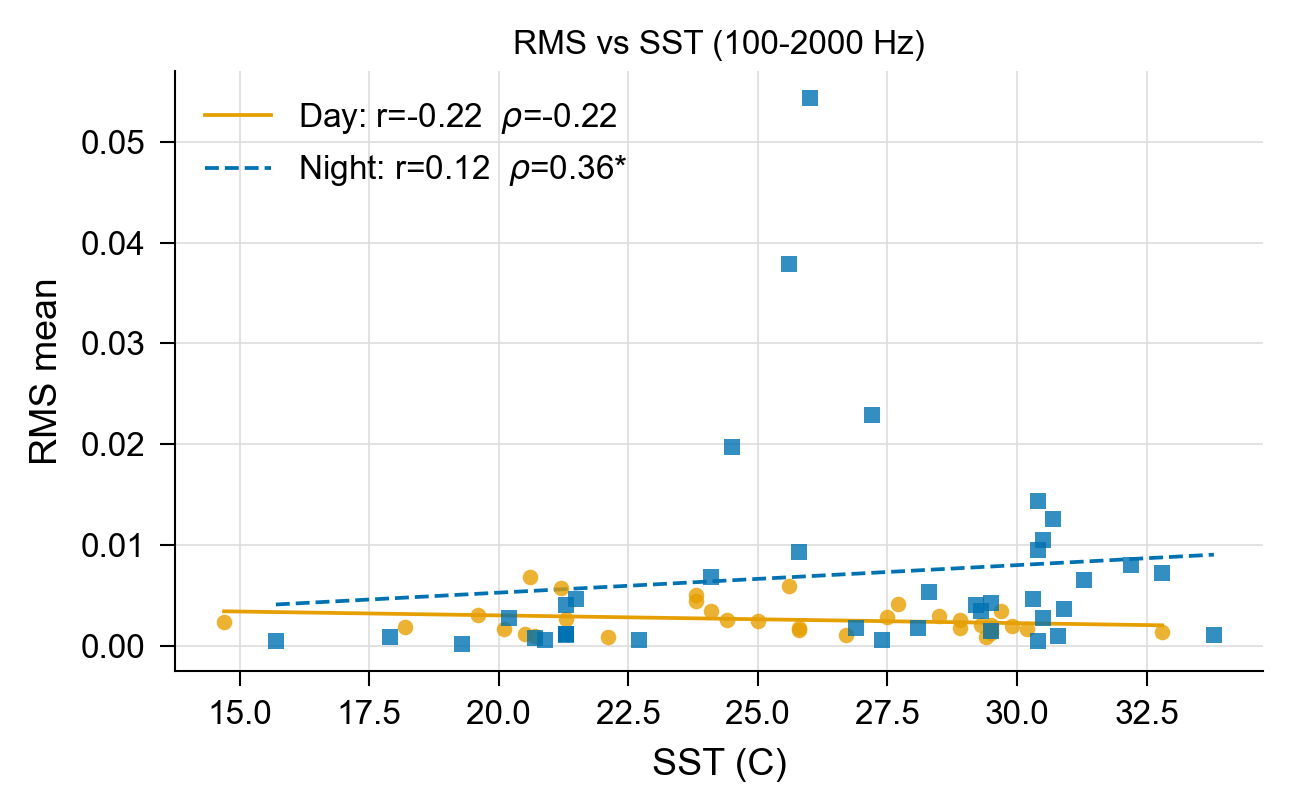

  saved: Fig5b_ZCR_SST.png


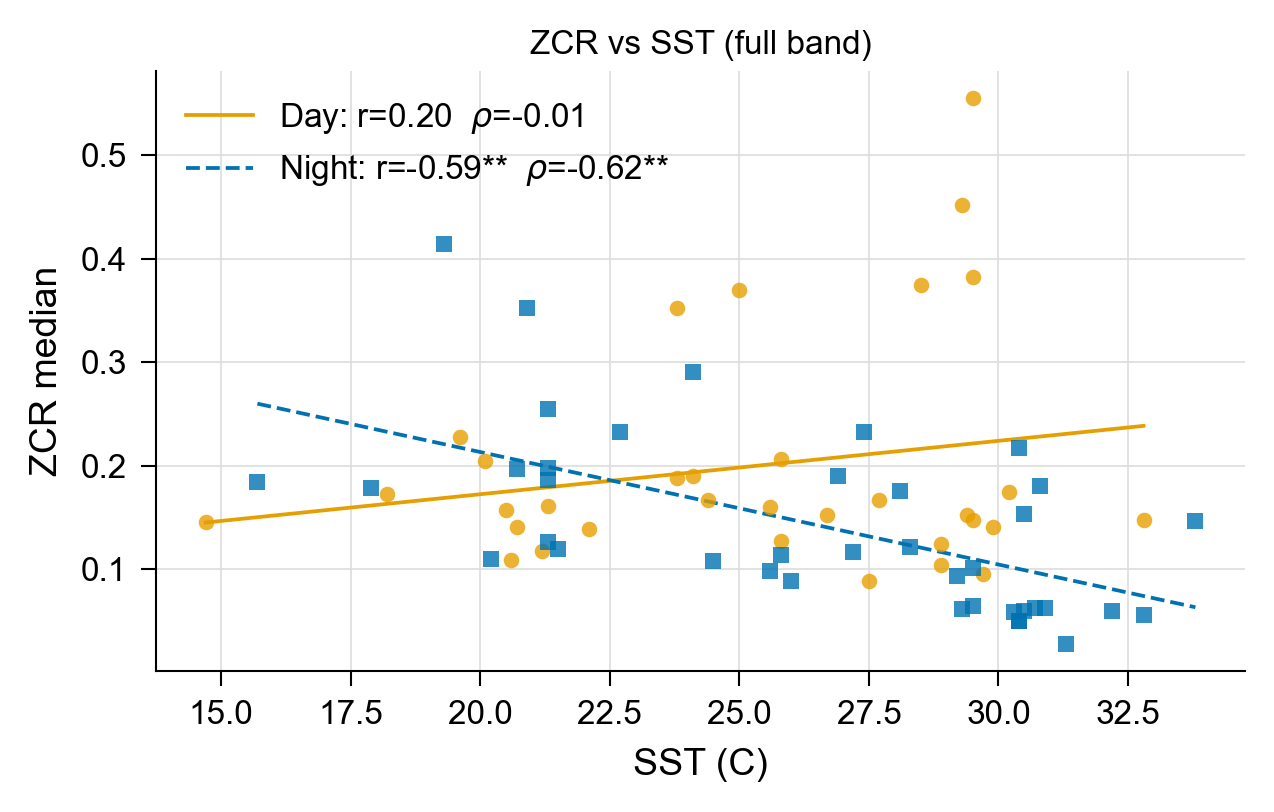

In [11]:
def env_scatter(df,xcol,ycol,xlabel,ylabel,title,fname):
    if df is None: print('Data not available'); return
    sub=df.dropna(subset=[xcol,ycol])
    fig,ax=plt.subplots(figsize=(FW*0.7,2.6))
    ax.spines[['top','right']].set_visible(False)
    ax.grid(color='#DDD',lw=0.4)
    for night,col2,mk,ls,lbl in [
        (False,DAY_COL,DAY_MK,DAY_LS,'Day'),
        (True,NIGHT_COL,NIGHT_MK,NIGHT_LS,'Night')]:
        s2=sub[sub['night']==night]
        if s2.empty: continue
        # Scatter label: use lbl if no OLS line (n<4), else OLS line carries label
        sc_label = lbl if len(s2) < 4 else ''
        ax.scatter(s2[xcol],s2[ycol],color=col2,marker=mk,
                   s=14,alpha=0.8,lw=0,zorder=3,label=sc_label)
        if len(s2)>=4:
            sl=linregress(s2[xcol],s2[ycol])
            rp,pp=pearsonr(s2[xcol],s2[ycol])
            rs,ps=spearmanr(s2[xcol],s2[ycol])
            def _star(p): return '' if p>=0.05 else '*' if p>=0.01 else '**'
            xr=np.linspace(s2[xcol].min(),s2[xcol].max(),200)
            ax.plot(xr,sl.slope*xr+sl.intercept,color=col2,lw=LW*1.2,ls=ls,
                    label=f'{lbl}: r={rp:.2f}{_star(pp)}  '+r'$\rho$'+f'={rs:.2f}{_star(ps)}')
    ax.set_xlabel(xlabel,fontsize=FS_AX); ax.set_ylabel(ylabel,fontsize=FS_AX)
    ax.set_title(title,fontsize=FS_TK,pad=4)
    ax.tick_params(labelsize=FS_TK); ax.legend(fontsize=FS_LG)
    savefig(fig,fname); plt.show(); plt.close(fig)

env_scatter(mB,'sst','rms_mean','SST (C)','RMS mean',
    'RMS vs SST (100-2000 Hz)','Fig5a_RMS_SST.png')
env_scatter(mA,'sst','zcr_p50','SST (C)','ZCR median',
    'ZCR vs SST (full band)','Fig5b_ZCR_SST.png')

## Figure 6 — Against wind speed

  saved: Fig6a_RMS_Wind.png


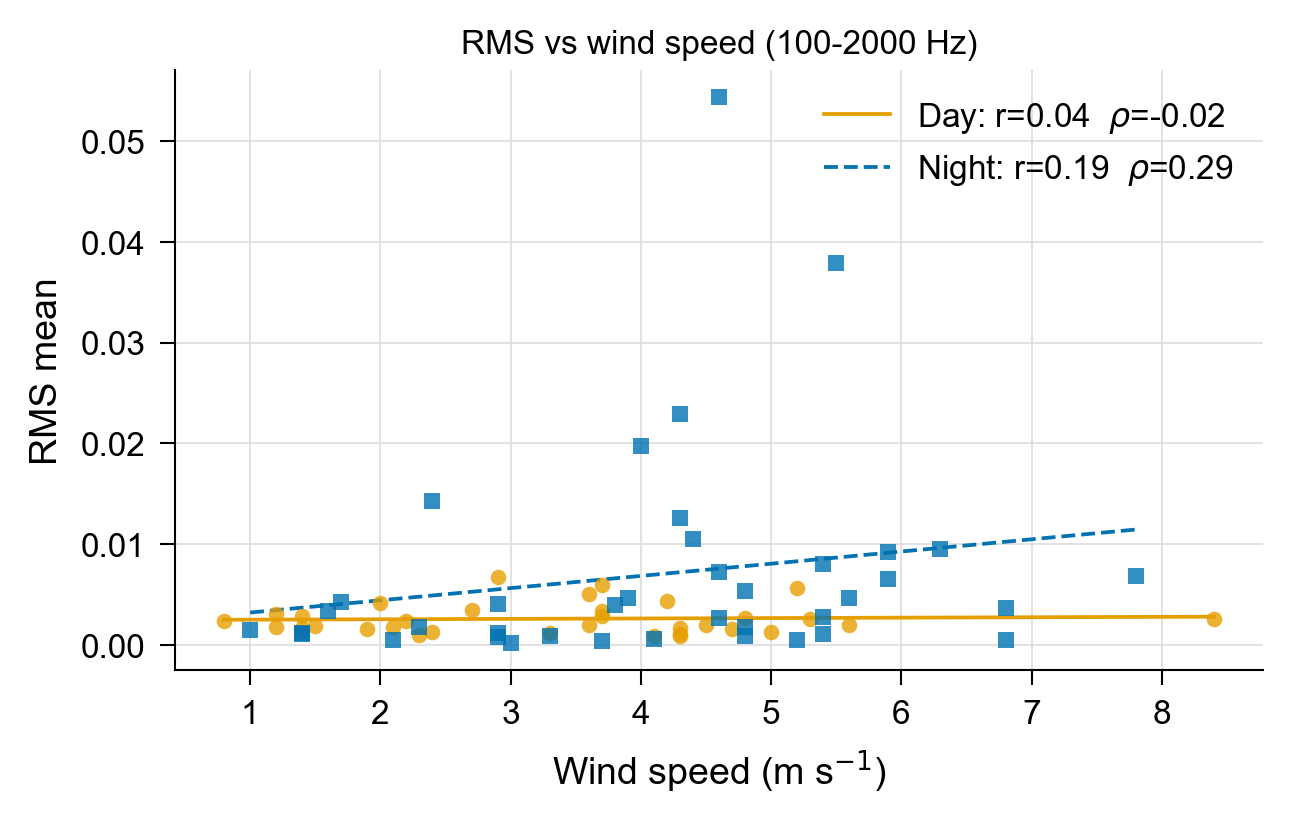

  saved: Fig6b_ZCR_Wind.png


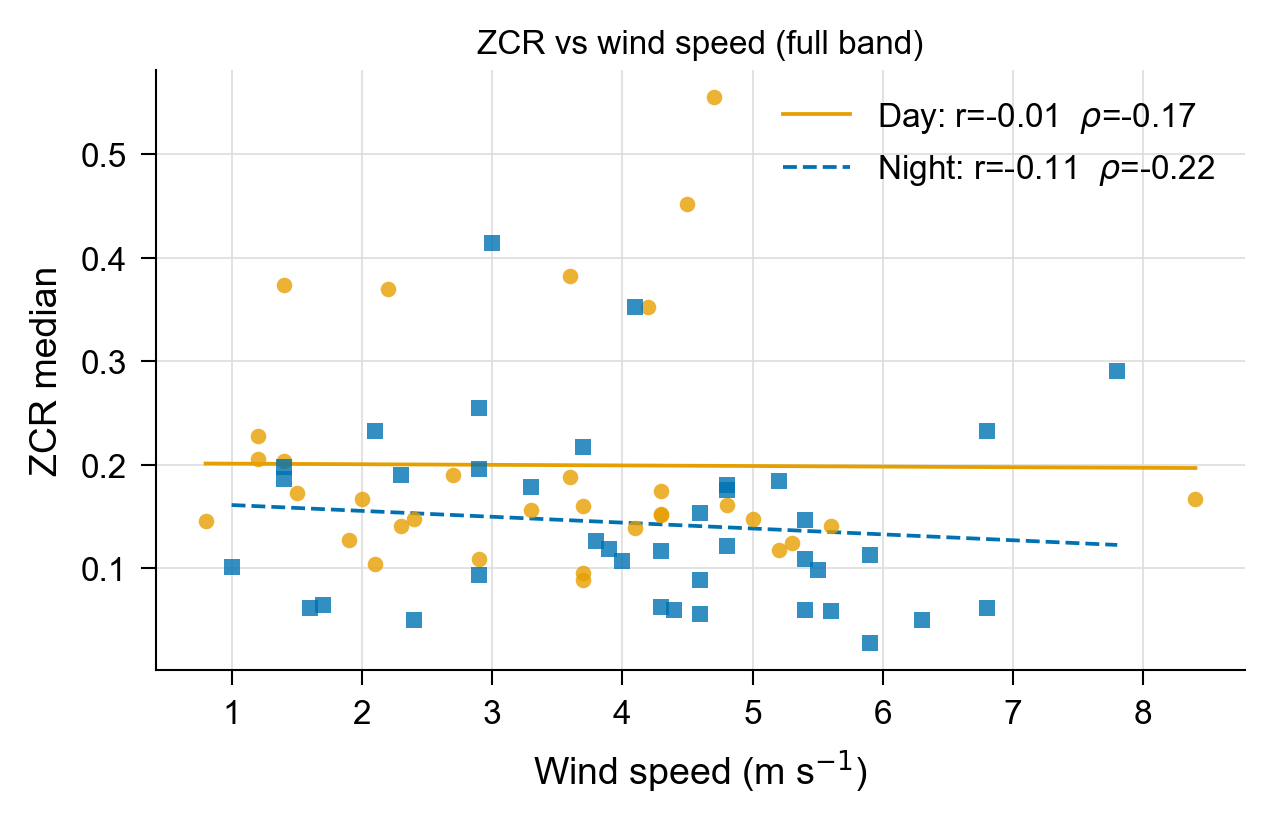

In [12]:
env_scatter(mB,'wspd','rms_mean',r'Wind speed (m s$^{-1}$)','RMS mean',
    'RMS vs wind speed (100-2000 Hz)','Fig6a_RMS_Wind.png')
env_scatter(mA,'wspd','zcr_p50',r'Wind speed (m s$^{-1}$)','ZCR median',
    'ZCR vs wind speed (full band)','Fig6b_ZCR_Wind.png')

## Figures 7 and 8 — Seasonal overlays

  saved: Fig7_SST_overlay.png


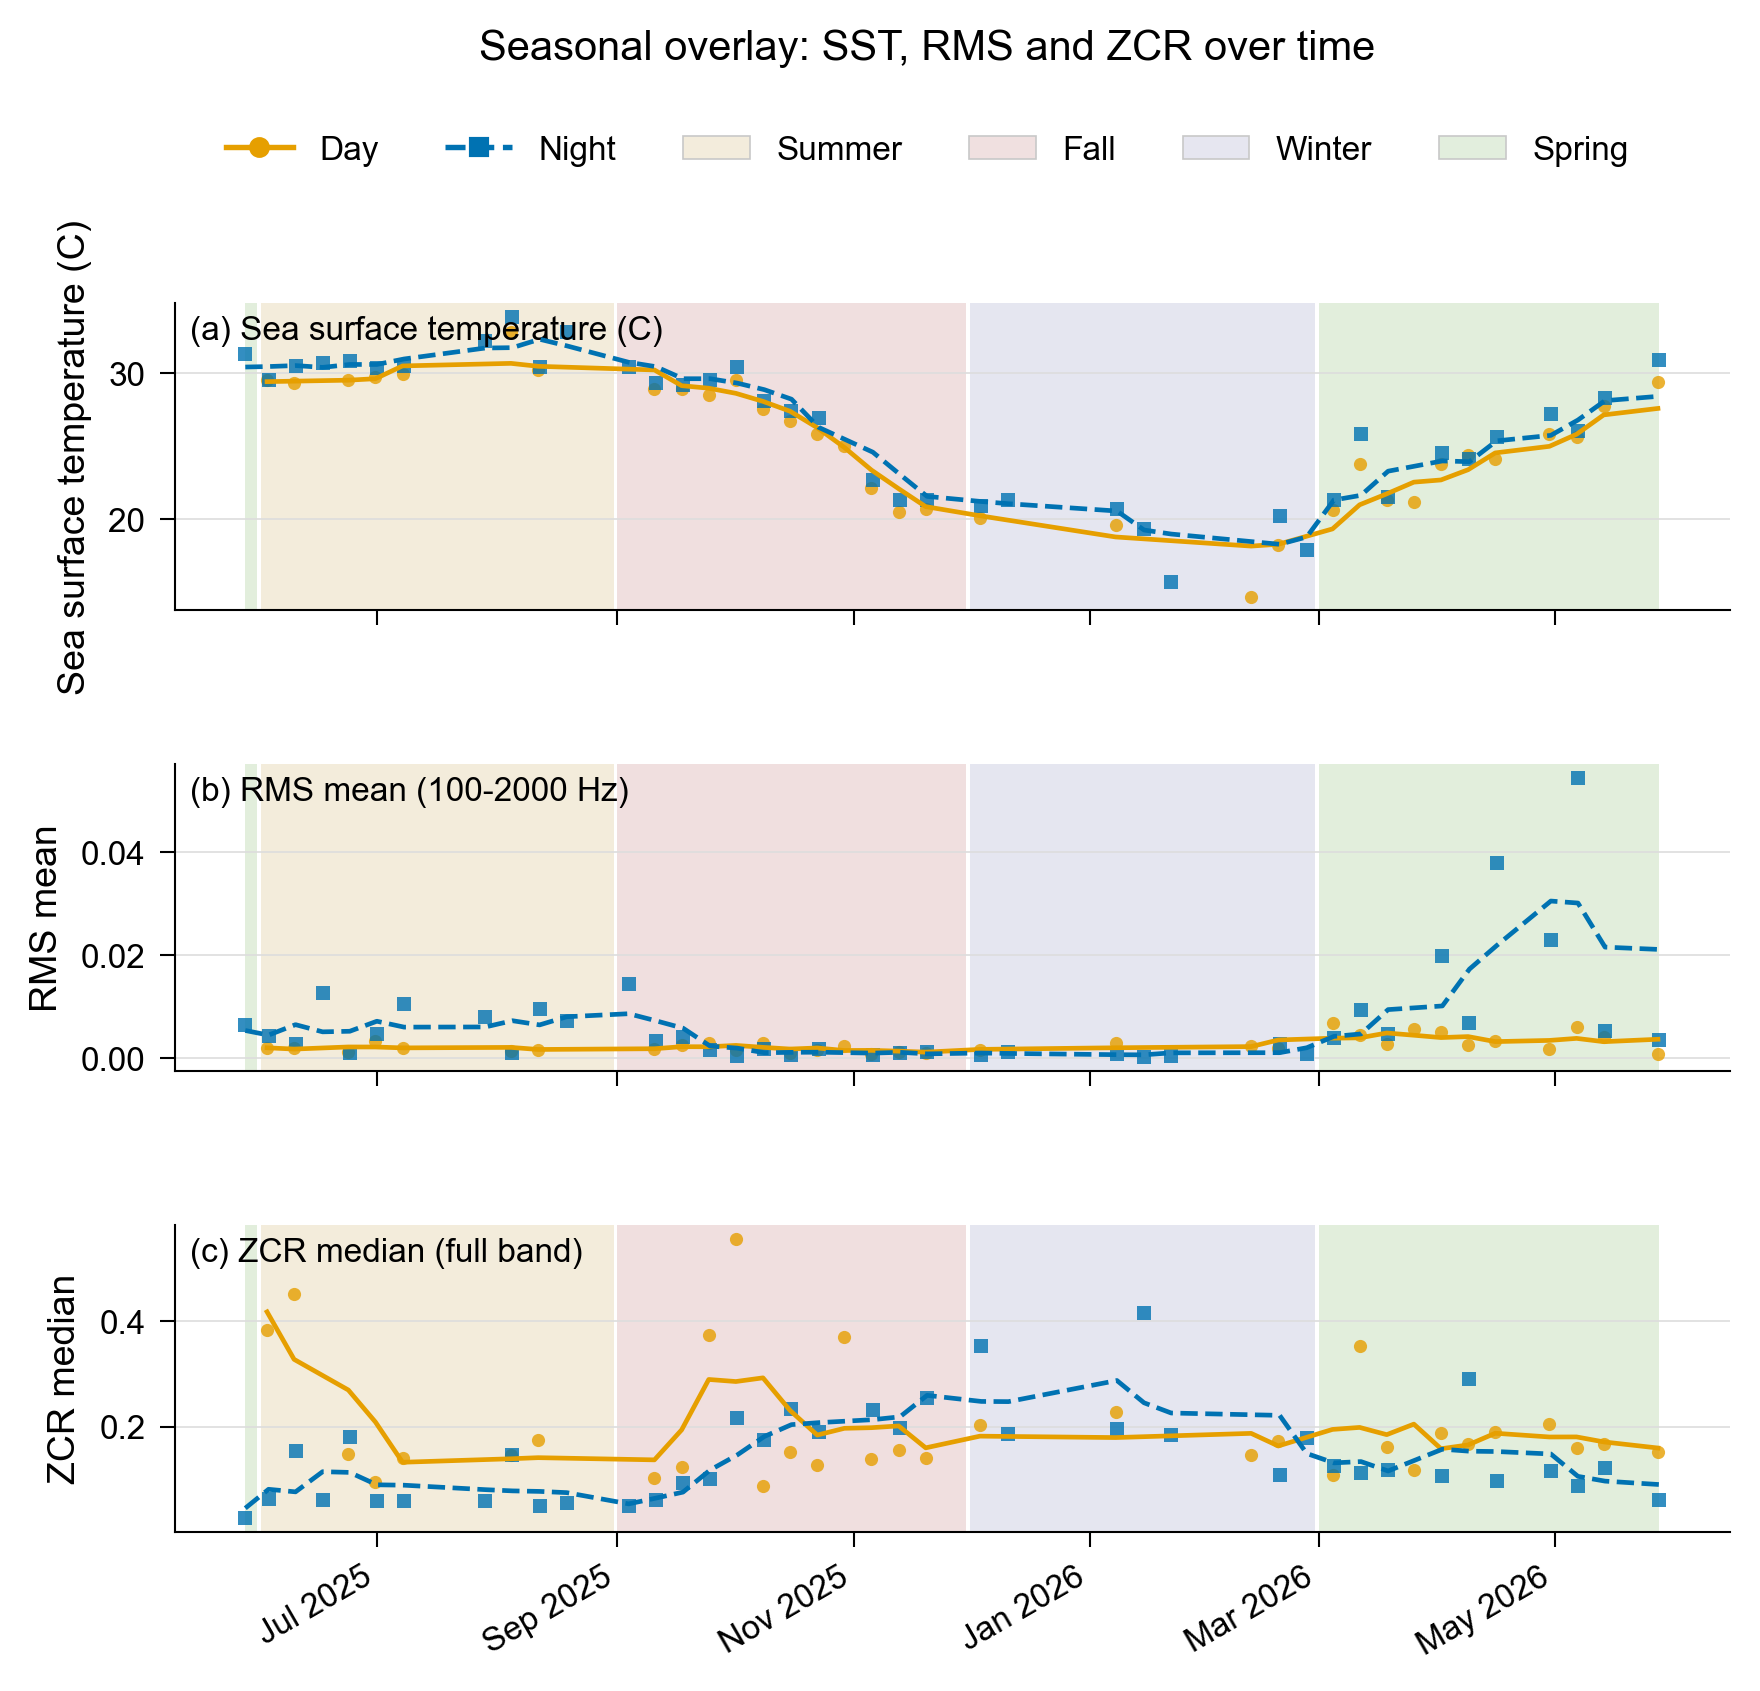

  saved: Fig8_Wind_overlay.png


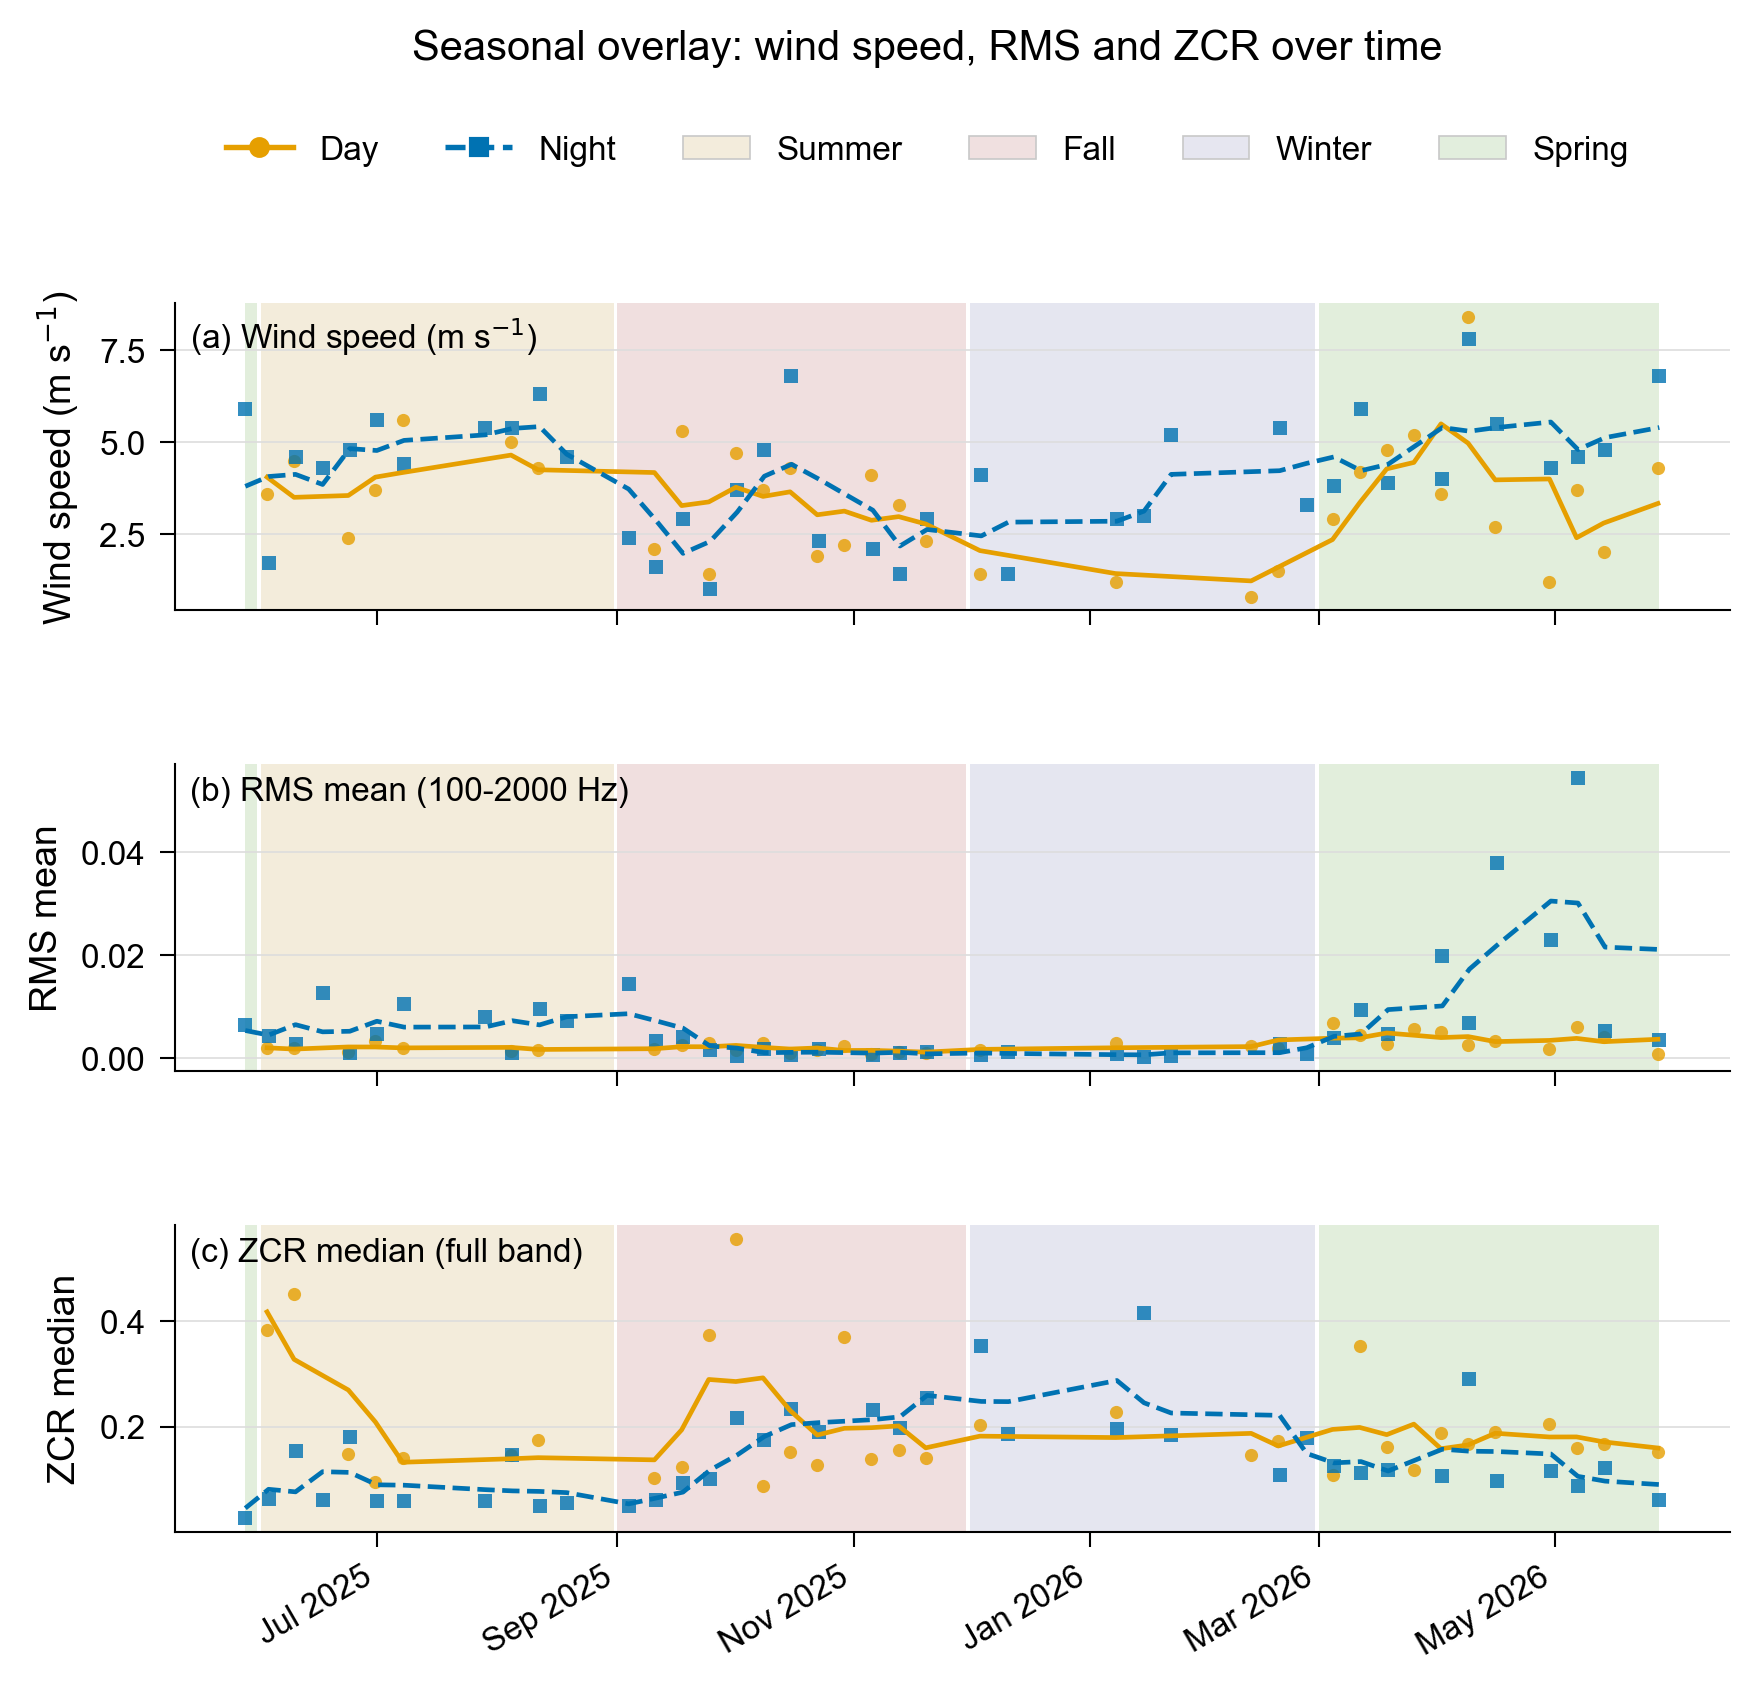

In [13]:
def overlay_plot(mB,mA,xcol,xlabel_env,fname,ttl_env,chart_title=''):
    if mA is None: print('Data not available'); return
    env_src=mB.dropna(subset=[xcol]).sort_values('dt')
    rms_src=smry_B.dropna(subset=['rms_mean']).sort_values('dt')
    zcr_src=smry_A.dropna(subset=['zcr_p50']).sort_values('dt')
    if env_src.empty: print('No data'); return
    all_dts_=[pd.to_datetime(r['dt']) for r in recordings if r['dt']]
    t_min=min(all_dts_) if all_dts_ else pd.to_datetime(env_src['dt']).min()
    t_max=max(all_dts_) if all_dts_ else pd.to_datetime(env_src['dt']).max()
    fig,axes=plt.subplots(3,1,figsize=(FW,6.3),sharex=True,gridspec_kw={'hspace':0.5})
    fig.subplots_adjust(top=0.85, bottom=0.10)
    if chart_title: fig.suptitle(chart_title, fontsize=FS_TT, y=0.995)
    srcs=[
        (axes[0],env_src, xcol, xlabel_env, f'(a) {ttl_env}'),
        (axes[1],rms_src,'rms_mean','RMS mean', '(b) RMS mean (100-2000 Hz)'),
        (axes[2],zcr_src,'zcr_p50','ZCR median', '(c) ZCR median (full band)'),
    ]
    for ax,df,col,yl,ttl in srcs:
        ax.spines[['top','right']].set_visible(False); ax.grid(axis='y',color='#DDD',lw=0.4)
        add_season_bg_dates(ax, t_min, t_max)
        for night,col2,mk,ls,lbl in [
            (False,DAY_COL,DAY_MK,DAY_LS,'Day'),(True,NIGHT_COL,NIGHT_MK,NIGHT_LS,'Night')]:
            sub=df[df['night']==night].dropna(subset=[col])
            if sub.empty: continue
            dts=pd.to_datetime(sub['dt'])
            ax.scatter(dts,sub[col],color=col2,marker=mk,s=10,alpha=0.8,lw=0,zorder=3)
            if len(sub)>=4:
                sub2=sub.sort_values('dt'); roll=sub2[col].rolling(4,min_periods=1,center=True).mean()
                ax.plot(pd.to_datetime(sub2['dt']),roll,color=col2,lw=LW*1.5,ls=ls,zorder=4)
        ax.set_ylabel(yl,fontsize=FS_AX)
        ax.text(0.01,0.96,ttl,transform=ax.transAxes,ha='left',va='top',fontsize=FS_TK)
        ax.tick_params(labelsize=FS_TK)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')); fig.autofmt_xdate(rotation=30,ha='right')
    fig.legend(handles=dn_season_handles(), loc='upper center', ncol=6, fontsize=FS_LG,
               frameon=False, bbox_to_anchor=(0.5,0.955))
    savefig(fig,fname); plt.show(); plt.close(fig)

overlay_plot(mB,mA,'sst','Sea surface temperature (C)','Fig7_SST_overlay.png',
             'Sea surface temperature (C)',
             chart_title='Seasonal overlay: SST, RMS and ZCR over time')
overlay_plot(mB,mA,'wspd',r'Wind speed (m s$^{-1}$)','Fig8_Wind_overlay.png',
             r'Wind speed (m s$^{-1}$)',
             chart_title='Seasonal overlay: wind speed, RMS and ZCR over time')

## Figures written

In [14]:
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f}")
print(f"\n{os.path.relpath(OUT_DIR, BASE)}/")

  Fig1a_RMS_boxplot.png
  Fig1b_ZCR_boxplot.png
  Fig2a_RMS_DayNight.png
  Fig2b_ZCR_DayNight.png
  Fig3a_RMS_trend.png
  Fig3b_ZCR_trend.png
  Fig4a_RMS_harmonic.png
  Fig4b_ZCR_harmonic.png
  Fig5a_RMS_SST.png
  Fig5b_ZCR_SST.png
  Fig6a_RMS_Wind.png
  Fig6b_ZCR_Wind.png
  Fig7_SST_overlay.png
  Fig8_Wind_overlay.png

figures/eda/
